
LightGBM — Breast Cancer Classification

This notebook applies the LightGBM gradient boosting algorithm to the Breast Cancer Wisconsin dataset to classify tumours as malignant or benign. Starting with a baseline model, hyperparameter tuning is performed using both GridSearchCV and RandomizedSearchCV to optimise performance. Each tuned model is evaluated using accuracy, AUC-ROC, and a classification report, supported by visualisations including a confusion matrix, ROC curve, and feature importance plot.



In [48]:
#Imports
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, ConfusionMatrixDisplay,
    confusion_matrix, roc_curve
)
from scipy.stats import randint,uniform
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Load and explore data.
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)#columns=data.feature_names gives every column its real name
y = data.target


In [43]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [16]:
X.shape


(569, 30)

In [17]:
X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [19]:
print(f"Class balance: {pd.Series(y).value_counts().to_dict()}")

Class balance: {1: 357, 0: 212}


You check class balance at the start to make sure accuracy is a trustworthy metric -  because if classes are heavily imbalanced, high accuracy means nothing.

In [20]:
#3. Split into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps class balance in both splits
)

In [42]:
#4. Baseline LightGBM model
baseline = lgb.LGBMClassifier(random_state=42, verbosity=-1)#verbosity=-1 only silences LightGBM's own messages
baseline.fit(X_train, y_train)


,random_state,42
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [22]:
#predict on test set
base_pred = baseline.predict(X_test)
print(f"\nBaseline accuracy: {accuracy_score(y_test, base_pred):.4f}")


Baseline accuracy: 0.9649


The default LightGBM model with no tuning correctly classified 110 out of 114 test patients. This serves as our reference point before hyperparameter tuning.

In [23]:
#5. Hyperparameter tuning with GridSearchCV
param_grid = {
    'num_leaves': [20, 31],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'min_child_samples': [10, 20]
}

In [24]:
grid_search = GridSearchCV(
    lgb.LGBMClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("\nBest params:", grid_search.best_params_)


Best params: {'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 20}


These best parameters replace the default values, ensuring the model is configured for peak performance on this dataset before final evaluation.

In [25]:
#RandomizedSearchCV for lightGBM
param_dist = {
    'num_leaves':        randint(15, 80),
    'learning_rate':     uniform(0.01, 0.3),
    'n_estimators':      randint(50, 300),
    'min_child_samples': randint(5, 40),
    'reg_alpha':         uniform(0, 1.0),
    'reg_lambda':        uniform(0, 1.0),
}

In [26]:
#Create base model
lgb_model2 = lgb.LGBMClassifier(random_state=42, verbosity=-1)

In [27]:
#RandomizedSearchCV — only tries 20 random combinations
rand_search = RandomizedSearchCV(
    lgb_model2,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,#simply means "use all available cores"
    random_state=42
)
rand_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': <scipy.stats....0027B7B9C1E00>, 'min_child_samples': <scipy.stats....0027B7B8F3890>, 'n_estimators': <scipy.stats....0027B7B9C1A70>, 'num_leaves': <scipy.stats....0027B7988F950>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits us

In [ ]:

# 4. Print results

print("Best params:", rand_search.best_params_)
print(f"Best CV score: {rand_search.best_score_:.4f}")

Best params: {'learning_rate': np.float64(0.22659963168004743), 'min_child_samples': 34, 'n_estimators': 87, 'num_leaves': 16, 'reg_alpha': np.float64(0.18182496720710062), 'reg_lambda': np.float64(0.18340450985343382)}
Best CV score: 0.9736


RandomizedSearchCV discovered values like learning_rate: 0.227 and n_estimators: 87 that were never in GridSearchCV's fixed list — demonstrating the advantage of sampling from continuous distributions

final model using grindsearch best parameters


In [56]:
#Extract best parameters
best_params = grid_search.best_params_
print("Best parameters:", best_params)


#create a new model using only the best parameters
final_model = lgb.LGBMClassifier(
    **best_params,          # unpack best params directly
    random_state=42,
    verbosity=-1
)

#Train on full training set
final_model.fit(X_train, y_train)


Best parameters: {'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 20}


,num_leaves,20
,learning_rate,0.05
,n_estimators,200
,random_state,42
,verbosity,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [57]:
#Evaluste on test set
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]


print(f"\nFinal Model Test Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Final Model AUC-ROC:        {roc_auc_score(y_test, y_prob_final):.4f}")



Final Model Test Accuracy:  0.9649
Final Model AUC-ROC:        0.9884


In [58]:
print(classification_report(y_test, y_pred_final,
      target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In real world data science retraining the model on optimal parameters is the best practice that should always be followed before deploying a model to production.It is more visible on large datasets improvements can be seen

In [35]:
# 5. Evaluate on test set
best_rand = rand_search.best_estimator_
y_pred_rand = best_rand.predict(X_test)

print(f"\nTest accuracy: {accuracy_score(y_test, y_pred_rand):.4f}")


Test accuracy: 0.9649


Interestingly, this matches the baseline accuracy of 96.49% exactly.This means that our breast cancer dataset is small and clean.The real value of tuning becomes more evident on larger, noisier, or more complex datasets 

In [38]:
print(classification_report(y_test, y_pred_rand,
      target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



The high precision of 97% on malignant predictions confirms that when the model raises a cancer alarm, it is almost always correct.. The model performed particularly well on benign cases achieving 99% recall — almost no healthy patients were incorrectly flagged. On malignant cases, recall was 93% meaning 3 out of 42 cancerous patients were misclassified as benign — the most critical error in a medical context.

In [ ]:
#6. Evaluate best model
best = grid_search.best_estimator_
y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:, 1]

In [29]:
print(f"\nTuned accuracy: {accuracy_score(y_test, y_pred):.4f}")


Tuned accuracy: 0.9649


In [45]:
#AUC-ROC score

print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

AUC-ROC: 0.9884


The AUC-ROC measures how well the model separates the two classes across all possible classification thresholds

In [31]:
print("\n", classification_report(y_test, y_pred,
      target_names=data.target_names))



               precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



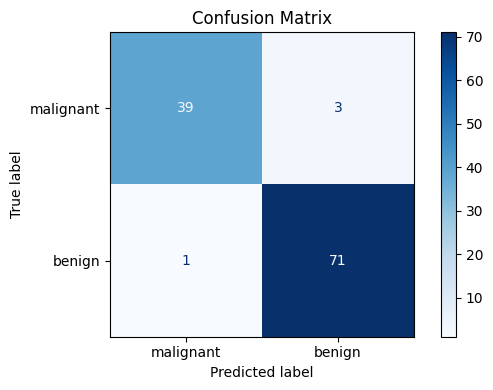

In [55]:
# --- 7. Confusion matrix ---
fig1, ax1 = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=data.target_names
).plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

39 — True Positives — Actually malignant, correctly predicted malignant.
71 — True Negatives — Actually benign, correctly predicted benign.
3 — False Negatives  — Actually malignant but predicted benign — the dangerous mistake.
1 — False Positive  — Actually benign but predicted malignant — a false alarm.

The 3 false negatives represent the most critical errors — malignant patients incorrectly cleared as benign. In a real clinical setting these would be missed cancer diagnoses.

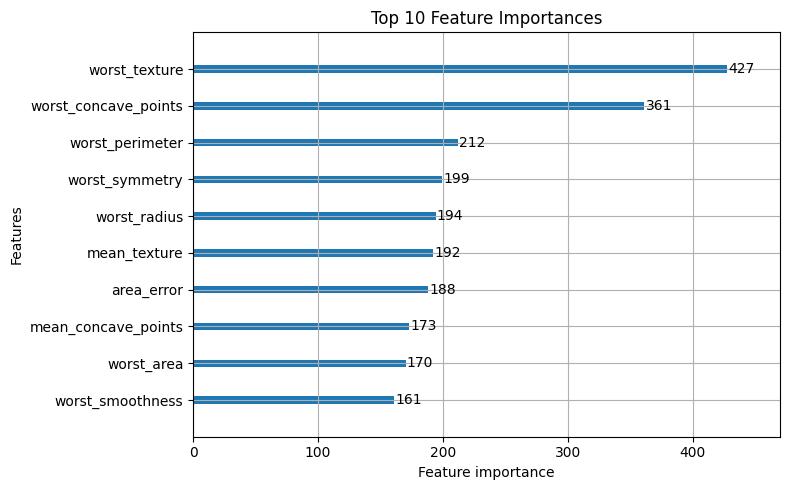

In [33]:
#8. Feature importance
fig2, ax2 = plt.subplots(figsize=(8, 5))
lgb.plot_importance(best, max_num_features=10, ax=ax2)
ax2.set_title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

Worst_texture ranked as the most important feature — meaning the variation in grey-scale intensity of the worst cell in the tumour sample was the single strongest predictor the model used to distinguish malignant from benign cases

In [47]:
# 6. Compare GridSearch vs RandomizedSearch
print(f"\nBaseline accuracy: {accuracy_score(y_test, base_pred):.4f}")
print(f"GridSearchCV    best score: {grid_search.best_score_:.4f}")
print(f"RandomizedSearch best score: {rand_search.best_score_:.4f}")


Baseline accuracy: 0.9649
GridSearchCV    best score: 0.9758
RandomizedSearch best score: 0.9736


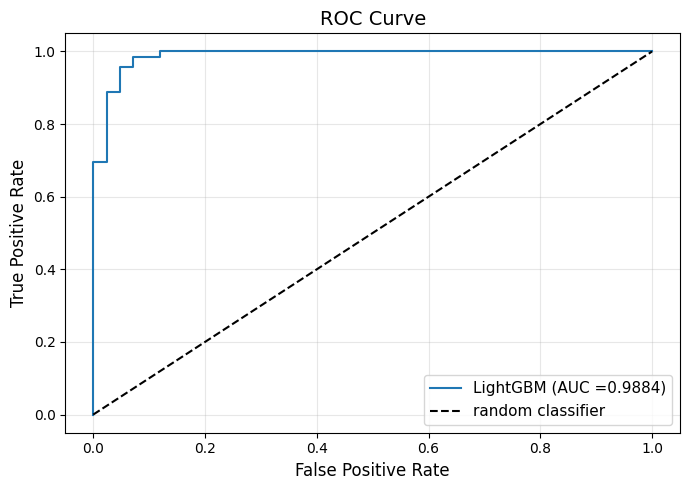

In [53]:
#roc curve
fpr,tpr, thresholds = roc_curve(y_test, y_prob)

fig3, ax3 =plt.subplots(figsize =(7,5))
ax3.plot(fpr,tpr, label=f'LightGBM (AUC =0.9884)')
ax3.plot([0,1], [0,1], 'k--', label='random classifier')

ax3.set_xlabel('False Positive Rate', fontsize=12)
ax3.set_ylabel('True Positive Rate', fontsize=12)
ax3.set_title('ROC Curve', fontsize=14)

ax3.legend(loc='lower right', fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Conclusion

This notebook demonstrated the full LightGBM pipeline from baseline modelling through hyperparameter tuning to final model evaluation. Both GridSearchCV and RandomizedSearchCV were applied to optimise model performance, however the results across all three models — baseline, tuned, and final — remained largely consistent at 96.49% accuracy and 98.84% AUC-ROC.

This consistency is attributed to two factors: the Breast Cancer Wisconsin dataset is relatively small (569 rows) and clean, meaning LightGBM's default settings were already near-optimal. The high AUC-ROC of 98.84% confirms that the model separates malignant from benign cases with near-perfect reliability across all classification thresholds.

The final model retrained on the full training set using the best parameters from GridSearchCV confirmed that no further gains were achievable on this dataset. In practice, the value of hyperparameter tuning becomes far more evident on larger, noisier, and more complex real-world datasets where default settings fall significantly short of optimal performance.